# Lab04 - Regresión logística con scikit-learn

## Objetivo

En este laboratorio voy a entrenar un modelo de regresión logística usando `scikit-learn`.

La idea es usar el mismo dataset del Lab03 y comparar los resultados obtenidos por la librería con los obtenidos manualmente mediante:

- la función sigmoide;
- la función de coste logarítmica;
- el descenso de gradiente.

En el Lab03 implementé el proceso desde cero. En este laboratorio voy a usar una herramienta estándar de machine learning para ver cómo se hace en la práctica.

## Etapa 1 - Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt

horas_estudio = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0])
puntajes = np.array([42, 48, 51, 55, 58, 61, 57, 66, 72, 78, 84, 90])
x_train = horas_estudio
y_train = (puntajes >= 60).astype(int)

## Etapa 2 - Preparar los datos para scikit-learn

In [2]:
x = horas_estudio.reshape(-1, 1)
y = y_train

`scikit-learn` espera que las variables de entrada tengan forma de matriz.

En este caso, como tengo una sola variable (`horas de estudio`), convierto el vector `horas_estudio` en una matriz de una columna usando `reshape(-1, 1)`.

## Etapa 3 - Crear el modelo

In [3]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression()

Se crea un modelo de regresión logística utilizando la implementación de `scikit-learn`.

Este modelo se encargará de aprender automáticamente los parámetros `w` y `b` a partir de los datos.

## Etapa 4 - Entrenar el modelo

In [4]:
modelo.fit(x, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

El método `fit` entrena el modelo.

Internamente, `scikit-learn` utiliza algoritmos de optimización para encontrar los parámetros que minimizan la función de coste.

## Etapa 5 - Obtener probabilidades

El método `predict_proba` devuelve, para cada observación, la probabilidad estimada de pertenecer a cada clase.

Como este es un problema binario, devuelve dos columnas:

- la primera columna corresponde a la probabilidad de la clase `0`;
- la segunda columna corresponde a la probabilidad de la clase `1`.

En este laboratorio, la clase `1` representa que el estudiante aprueba.

In [5]:
probabilidades = modelo.predict_proba(x)
print(probabilidades)

probabilidad_aprobar = probabilidades[:, 1]
print (" ====================================================================")
for horas, prob in zip(x_train, probabilidad_aprobar):
    print(f"Horas: {horas} - Probabilidad de aprobar: {prob:.4f}")

[[0.97125951 0.02874049]
 [0.94686008 0.05313992]
 [0.90379827 0.09620173]
 [0.83203162 0.16796838]
 [0.72312794 0.27687206]
 [0.5793161  0.4206839 ]
 [0.42065198 0.57934802]
 [0.27684584 0.72315416]
 [0.16795008 0.83204992]
 [0.09619035 0.90380965]
 [0.05313333 0.94686667]
 [0.02873683 0.97126317]]
Horas: 0.5 - Probabilidad de aprobar: 0.0287
Horas: 1.0 - Probabilidad de aprobar: 0.0531
Horas: 1.5 - Probabilidad de aprobar: 0.0962
Horas: 2.0 - Probabilidad de aprobar: 0.1680
Horas: 2.5 - Probabilidad de aprobar: 0.2769
Horas: 3.0 - Probabilidad de aprobar: 0.4207
Horas: 3.5 - Probabilidad de aprobar: 0.5793
Horas: 4.0 - Probabilidad de aprobar: 0.7232
Horas: 4.5 - Probabilidad de aprobar: 0.8320
Horas: 5.0 - Probabilidad de aprobar: 0.9038
Horas: 5.5 - Probabilidad de aprobar: 0.9469
Horas: 6.0 - Probabilidad de aprobar: 0.9713


La matriz devuelta por `predict_proba` tiene dos columnas:

- la primera columna representa la probabilidad de pertenecer a la clase `0`;
- la segunda columna representa la probabilidad de pertenecer a la clase `1`.

En este ejemplo, la clase `1` representa que el estudiante aprueba.

Por eso se toma:

`probabilidades[:, 1]`

para obtener solamente la probabilidad estimada de aprobar.

## Etapa 6 - Obtener clases estimadas

El método `predict` devuelve la clase estimada por el modelo.

En regresión logística, primero se calcula una probabilidad. Luego, usando un umbral, se convierte esa probabilidad en una clase.

Por defecto, para clasificación binaria, `scikit-learn` usa un umbral de `0.5`:

- si la probabilidad de la clase `1` es mayor o igual a `0.5`, predice `1`;
- si es menor a `0.5`, predice `0`.

In [6]:
clases_estimadas = modelo.predict(x)

print(clases_estimadas)

[0 0 0 0 0 0 1 1 1 1 1 1]


In [7]:
for horas, real, estimado in zip(x_train, y_train, clases_estimadas):
    print(f"Horas: {horas} - Real: {real} - Estimado: {estimado}")

Horas: 0.5 - Real: 0 - Estimado: 0
Horas: 1.0 - Real: 0 - Estimado: 0
Horas: 1.5 - Real: 0 - Estimado: 0
Horas: 2.0 - Real: 0 - Estimado: 0
Horas: 2.5 - Real: 0 - Estimado: 0
Horas: 3.0 - Real: 1 - Estimado: 0
Horas: 3.5 - Real: 0 - Estimado: 1
Horas: 4.0 - Real: 1 - Estimado: 1
Horas: 4.5 - Real: 1 - Estimado: 1
Horas: 5.0 - Real: 1 - Estimado: 1
Horas: 5.5 - Real: 1 - Estimado: 1
Horas: 6.0 - Real: 1 - Estimado: 1


## Etapa 7 - Comparación de parámetros

En el Lab03 se calcularon los parámetros `w` y `b` utilizando descenso de gradiente.

En este laboratorio, `scikit-learn` calcula esos parámetros automáticamente.

Se comparan ambos resultados para verificar que son similares.

#### Los siguientes valores corresponden a la salida obtenida en el Lab03 utilizando descenso de gradiente.

In [8]:
#salidas del laboratorio 3
w_manual = 1.934251988205962
b_manual = -6.181490783590346
costefinal = 0.2189435264230269
iteraciones = 2000

In [9]:
w_sklearn = modelo.coef_[0][0]
b_sklearn = modelo.intercept_[0]

print(f"w manual:    {w_manual}")
print(f"w sklearn:   {w_sklearn}")

print(f"b manual:    {b_manual}")
print(f"b sklearn:   {b_sklearn}")

w manual:    1.934251988205962
w sklearn:   1.2801281493543428
b manual:    -6.181490783590346
b sklearn:   -4.160351008907018


Los parámetros obtenidos no son exactamente iguales.

Esto se debe a que:

- la implementación manual utiliza descenso de gradiente;
- `scikit-learn` utiliza algoritmos de optimización más avanzados.

Sin embargo, ambos modelos generan predicciones similares.

## Etapa 8 - Comparación de predicciones

Se comparan las clases estimadas por el modelo manual y por `scikit-learn`.

Si ambos modelos aprendieron una frontera de decisión similar, las predicciones deberían coincidir o ser muy parecidas.

In [10]:
pred_manual = []

for horas in x_train:
    z = w_manual * horas + b_manual
    prob = 1 / (1 + np.exp(-z))
    pred_manual.append(1 if prob >= 0.5 else 0)

pred_manual = np.array(pred_manual)

print("Predicciones manuales:", pred_manual)
print("Predicciones sklearn: ", clases_estimadas)

Predicciones manuales: [0 0 0 0 0 0 1 1 1 1 1 1]
Predicciones sklearn:  [0 0 0 0 0 0 1 1 1 1 1 1]


## Etapa 9 - Visualización del modelo

Para visualizar el modelo entrenado, se grafica la probabilidad estimada de aprobar según las horas de estudio.

La línea horizontal en `0.5` representa el umbral de decisión utilizado para convertir probabilidades en clases.

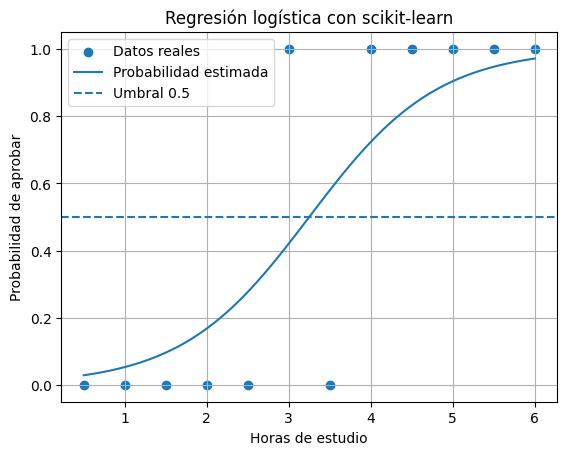

In [11]:
x_grafica = np.linspace(x_train.min(), x_train.max(), 100).reshape(-1, 1)
prob_grafica = modelo.predict_proba(x_grafica)[:, 1]

plt.scatter(x_train, y_train, label="Datos reales")
plt.plot(x_grafica, prob_grafica, label="Probabilidad estimada")
plt.axhline(y=0.5, linestyle="--", label="Umbral 0.5")

plt.xlabel("Horas de estudio")
plt.ylabel("Probabilidad de aprobar")
plt.title("Regresión logística con scikit-learn")
plt.grid(True)
plt.legend()
plt.show()

La forma de la curva coincide con la función sigmoide estudiada en el Lab03.

## Conclusión

En este laboratorio se utilizó `scikit-learn` para entrenar un modelo de regresión logística.

Se comparan ambos resultados para observar si, aunque los parámetros no sean exactamente iguales, ambos modelos producen una frontera de decisión similar.

Aunque los parámetros no son exactamente iguales, ambos modelos aprendieron una frontera de decisión similar y generaron las mismas clases estimadas para este dataset.